# PBMRS on FX: can a fragility statistic precede short-covering episodes?
**GMSG application work sample - FX coverage | Salman**

The companion [WTI study](02_wti_regime_calibration.ipynb) exposed a scale mismatch and
unstable high-J non-rejections. Its April sensitivity weakened the original inference.
That failure motivates this experiment. A lower FX volatility scale makes a new test
feasible; feasibility alone does not establish that PBMRS measures carry fragility.

This notebook tests one predeclared JPY association, displays EUR as a falsification,
and keeps every secondary result visible. GMSG's FX report was unavailable: no claim
from an unseen report is attributed to the group.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pbmrs_core import __version__, SimConfig, load_config
from pbmrs_core.calibration import load_npz_cache
from pbmrs_core.fx import fetch_fx, discover_definitions, fetch_fx_positioning, validate_raw_tree
from pbmrs_core.fx_analysis import load_study

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "Public Repo"]
ROOT = next(p for p in candidates if (p / "configs/fx_study.json").exists())
CACHE = ROOT / "notebooks/fx_cache"
frozen, sim, manifest, result = load_study(ROOT)
design = frozen["design"]
cfg = SimConfig(**load_config(ROOT / "configs/base.yaml")["simulation"])
assert __version__ == "0.2.2" and cfg.alpha_r == 12.0
assert design["primary"] == frozen["design"]["primary"]
assert design["n_stability"] == 500 and design["n_pseudo"] >= 300
assert design["seeds"]["calibration"][1] < design["seeds"]["null"][0]
assert frozen["registered_at_utc"] < sim["started_at_utc"] < manifest["computed_at_utc"]
series = {pair: fetch_fx(pair, cache_dir=CACHE / "raw", start=design["start"], end=design["end"])
          for pair in ("JPY", "EUR")}
assert series["JPY"].source == "FRED / Federal Reserve Board, H.10"
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False,
                    "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18,
                    "font.size": 10, "axes.titlesize": 12})
colors = {"JPY": "#147d92", "EUR": "#c56a2d"}
display(pd.DataFrame([design["primary"]]))
display(pd.DataFrame(sim["scale"]).T.drop(columns="trace"))
print("Registered:", frozen["registered_at_utc"], "| design SHA-256:", frozen["design_sha256"])
print("Calibration/null:", design["n_cal"], design["n_null"], "| burn:", design["burn"])
primary_summary = next(row for row in result["specifications"] if row["primary"])
display(Markdown(f"**Primary outcome: {primary_summary['status']}.** "
                 f"{primary_summary['n_labelled']} held-out episodes; {primary_summary['n_matched']} matched. "
                 "Insufficient events is not a statistically tested null."))

,pair,window,K,alpha,alternative,outcome,sample
0,JPY,500,21,0.1,greater,pre-episode minimum-distance J minus volatilit...,held-out 2018 onward


,sigma_eps,target_sd,matched_sd,relative_error,training_n,training_end,reference_J
JPY,0.005456,0.006183,0.006195,0.001887,2003,2017-12-29,0.4
EUR,0.005163,0.005907,0.005878,0.004974,2003,2017-12-29,0.4


Registered: 2026-09-15T15:38:58.123878+00:00 | design SHA-256: d5bd9607cbae2c0f1bfa7b027c9d0efb8d6fcb900db8be5ae00998ca9498637b
Calibration/null: 500 999 | burn: 500


**Primary outcome: insufficient_events.** 5 held-out episodes; 2 matched. Insufficient events is not a statistically tested null.

## What is being tested

The primary outcome is the difference in **minimum-distance J** before retrospectively labelled
JPY short-covering episodes versus volatility-matched non-episode dates: 500-session estimation,
K=21 prior sessions, one-sided alpha=0.10, validation from 2018 onward. The 250-session specification
is secondary. CFTC enters episode labels and context only; J inference uses returns alone.

Total model volatility is solved against pre-2018 realized SD at reference J=0.40, with a 0.5%
numerical tolerance, then frozen. Matching volatility separately at every J would define a
different model family. J is therefore conditional on this fixed nuisance calibration.

## Exhibit 1 - Why move from crude to FX?

The table below reproduces the **prior measurements supplied in the build brief** (250 paths,
2,000 evaluation sessions). These are motivation, not newly replicated results; the brief did
not supply their raw paths or seed ledger. The following exhibit is the new 500-path screen.
Prior flow-share numbers describe the measured structural channel and are not a causal
variance decomposition of observed FX returns.

,analogue,sigma_eps,pathological_J040,pathological_J078,flow_share_J040,flow_share_J078
0,EURUSD,0.0045,0.000,0.000,0.24,0.41
1,SPX,0.0110,0.000,0.048,0.20,NaN
2,WTI,0.0418,0.992,1.000,NaN,NaN


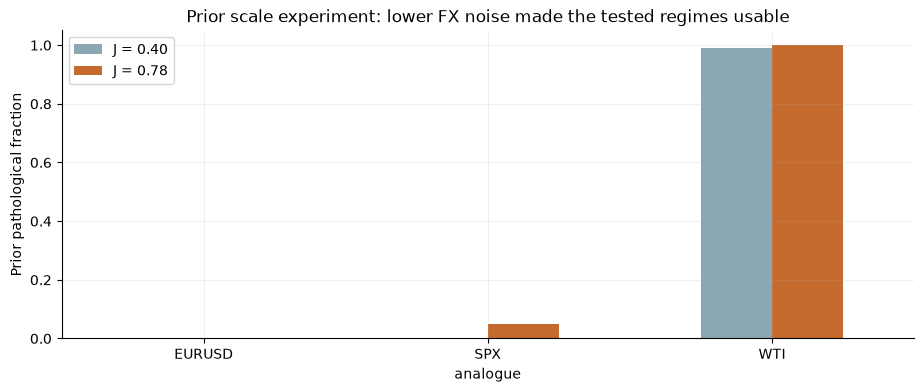

In [2]:
prior = pd.DataFrame(design["historical_scale_evidence"]["rows"])
display(prior)
ax = prior.set_index("analogue")[["pathological_J040", "pathological_J078"]].plot.bar(
    color=["#8ba7b3", "#c56a2d"], rot=0)
ax.set(ylabel="Prior pathological fraction", title="Prior scale experiment: lower FX noise made the tested regimes usable")
ax.legend(["J = 0.40", "J = 0.78"])
plt.show()

## Exhibit 2 - New stability screen at each solved FX scale

Each tested J uses 500 independent paths and 2,000 post-burn returns. Pathology means
non-finite values, invariant failure, or return SD above 5 times innovation sigma. The eligibility
rule is an observed rate at most 1%; Wilson intervals show sampling uncertainty, so zero
observed failures does not prove zero risk. J*beta=1 is an agent-layer reference, not an
established boundary of the coupled market system.

**JPY eligible tested points:** [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.78, 0.8, 0.82, 0.8333333333333334, 0.85]

**EUR eligible tested points:** [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.78, 0.8, 0.82, 0.8333333333333334, 0.85]

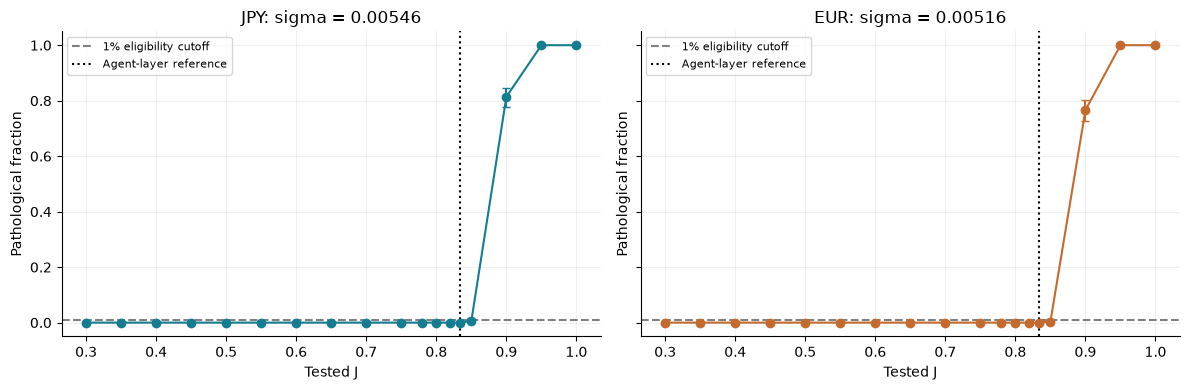

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pair in zip(axes, ("JPY", "EUR")):
    table = pd.DataFrame(sim["stability"][pair])
    ax.errorbar(table.J, table.fraction,
                yerr=np.maximum(0, [table.fraction-table.lo, table.hi-table.fraction]), fmt="o-", color=colors[pair], capsize=3)
    ax.axhline(.01, color="grey", ls="--", label="1% eligibility cutoff")
    ax.axvline(1/cfg.beta, color="black", ls=":", label="Agent-layer reference")
    ax.set(title=f"{pair}: sigma = {sim['scale'][pair]['sigma_eps']:.5f}", xlabel="Tested J", ylabel="Pathological fraction")
    ax.legend(fontsize=8)
    display(Markdown(f"**{pair} eligible tested points:** {sim['eligible'][pair]}"))
plt.tight_layout(); plt.show()

## Exhibit 3 - Quote direction and positioning context

Both series are **USD per foreign-currency unit**: JPY appreciation is positive after
inverting [FRED DEXJPUS](https://fred.stlouisfed.org/series/DEXJPUS); EUR uses
[DEXUSEU](https://fred.stlouisfed.org/series/DEXUSEU) directly. Raw FX observations are
Federal Reserve Board H.10 noon buying rates, not exchange closing prices. Missing
observations are dropped, with no holiday forward-fill.

[CFTC financial contracts](https://publicreporting.cftc.gov/stories/s/r4w3-av2u) use TFF
leveraged money, not disaggregated managed money. Contract codes were discovered by exact
CME contract name from official rows. Net short exposure = (short-long)/OI; short covering
reduces this measure and increases conventional (long-short)/OI. COT covers futures and
cannot measure the entire OTC carry market or identify why traders held positions.

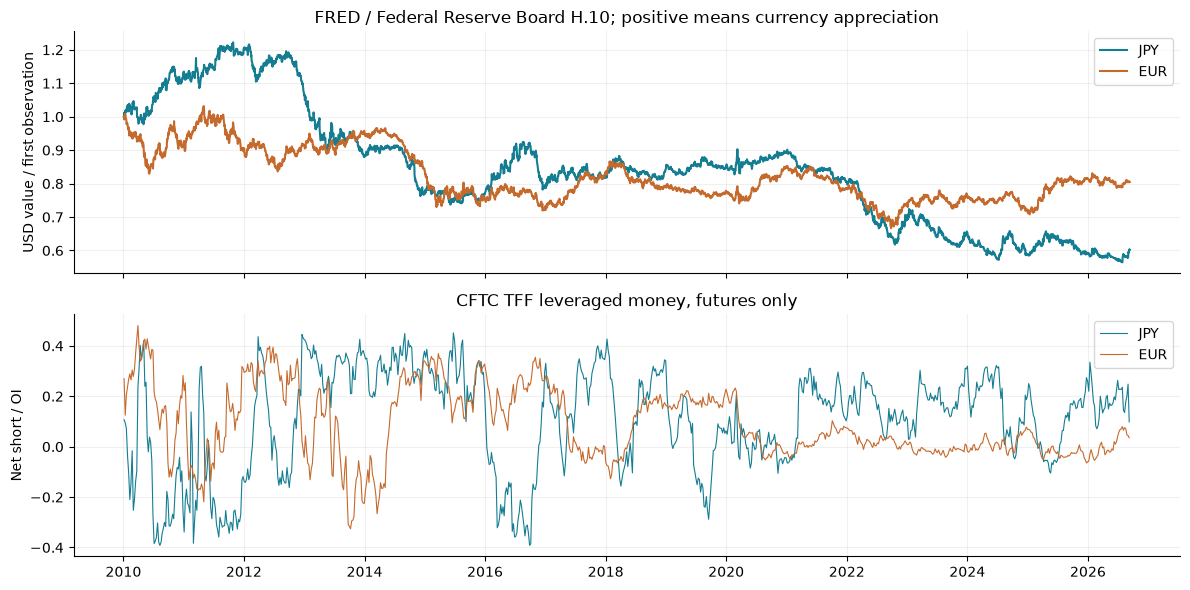

,pair,definition,category,reports,last_date,last_net_oi,mean_net_oi
0,JPY,legacy_futures,noncommercial,871,2026-09-08,0.021608,-0.135166
1,JPY,legacy_combined,noncommercial,871,2026-09-08,0.023107,-0.123643
2,JPY,tff_futures,leveraged_money,871,2026-09-08,-0.098268,-0.107506
3,JPY,tff_combined,leveraged_money,871,2026-09-08,-0.097858,-0.099341
4,EUR,legacy_futures,noncommercial,871,2026-09-08,-0.045218,-0.035617
5,EUR,legacy_combined,noncommercial,871,2026-09-08,-0.058255,-0.027946
6,EUR,tff_futures,leveraged_money,871,2026-09-08,-0.035317,-0.087019
7,EUR,tff_combined,leveraged_money,871,2026-09-08,-0.043900,-0.079652


In [4]:
definitions = discover_definitions(CACHE / "raw")
context = []
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for pair in ("JPY", "EUR"):
    fx = series[pair]
    axes[0].plot(fx.dates, fx.close/fx.close[0], label=pair, color=colors[pair])
    definition = next(d for d in definitions if d.key == design["positioning_primary"])
    cot, contract = fetch_fx_positioning(definition, pair, cache_dir=CACHE / "raw", start=design["start"], end=design["end"])
    axes[1].plot(cot.dates, -cot.net_over_oi, label=pair, color=colors[pair], lw=.8)
    for key, values in result["pairs"][pair]["positioning"].items():
        context.append({"pair": pair, "definition": key, **{k:v for k,v in values.items() if k != "contract"}})
axes[0].set(ylabel="USD value / first observation", title="FRED / Federal Reserve Board H.10; positive means currency appreciation")
axes[1].set(ylabel="Net short / OI", title="CFTC TFF leveraged money, futures only")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame(context))

## Exhibit 4 - Empirical fingerprint and the tail gap

The shared statistic is ACF of demeaned squared returns, lags 1-8. Pointwise 95% stationary
bootstrap intervals use 1,000 draws and mean block length 21. These describe the entire
historical mixture; they do not establish constant J over the sample. SD and excess
kurtosis are separate diagnostics: the selected ACF distance does not test tail adequacy.

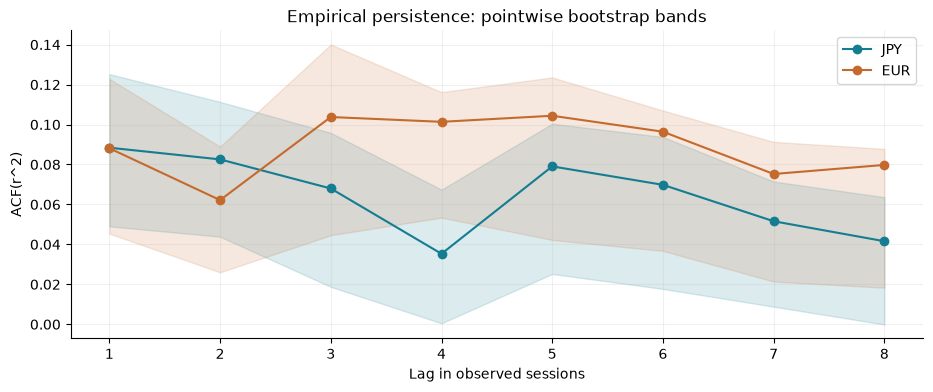

,pair,n_returns,daily_SD,excess_kurtosis,kurtosis_lo,kurtosis_hi
0,JPY,4175,0.005894,4.209342,3.097425,5.442965
1,EUR,4175,0.005183,1.830085,1.321367,2.430915


,pair,J,mean,path_p025,path_p975,empirical,gap
0,JPY,0.40,0.001810,-0.186710,0.244793,4.209342,4.207532
1,JPY,0.78,-0.011910,-0.219679,0.215621,4.209342,4.221251
2,EUR,0.40,0.001974,-0.188932,0.247340,1.830085,1.828111
3,EUR,0.78,-0.012162,-0.221419,0.220887,1.830085,1.842248


In [5]:
fig, ax = plt.subplots()
fingerprint_rows = []
for pair in ("JPY", "EUR"):
    f = result["pairs"][pair]["fingerprint"]
    x = np.arange(1, 9)
    ax.plot(x, f["point"][:8], "o-", label=pair, color=colors[pair])
    ax.fill_between(x, f["lo"][:8], f["hi"][:8], alpha=.15, color=colors[pair])
    fingerprint_rows.append({"pair": pair, "n_returns": result["pairs"][pair]["n_returns"],
                             "daily_SD": f["point"][8], "excess_kurtosis": f["point"][9],
                             "kurtosis_lo": f["lo"][9], "kurtosis_hi": f["hi"][9]})
ax.set(xlabel="Lag in observed sessions", ylabel="ACF(r^2)", title="Empirical persistence: pointwise bootstrap bands")
ax.legend(); plt.show()
display(pd.DataFrame(fingerprint_rows))
display(pd.DataFrame([{ "pair": pair, **row } for pair in ("JPY", "EUR") for row in result["pairs"][pair]["kurtosis"]]))

## Exhibit 5 - Rolling JPY minimum-distance estimates

J_hat minimizes the same standardized D-sum used for adequacy. A higher p-value is not a better
fit. Shaded squares are the **exact non-rejected grid points**, a pointwise Neyman-inversion
set conditional on the fixed scale; gaps and empty sets remain visible. No continuous-J
interval or simultaneous coverage across dates is claimed. A closest grid point still
exists when the entire grid is rejected, but then it is an inadequate approximation.

Monthly steps reuse overlapping returns. The 250-session estimate responds faster and has
greater uncertainty; the 500-session estimate has a longer memory. Confidence sets may be
too broad to distinguish either. Both specifications were declared before results.

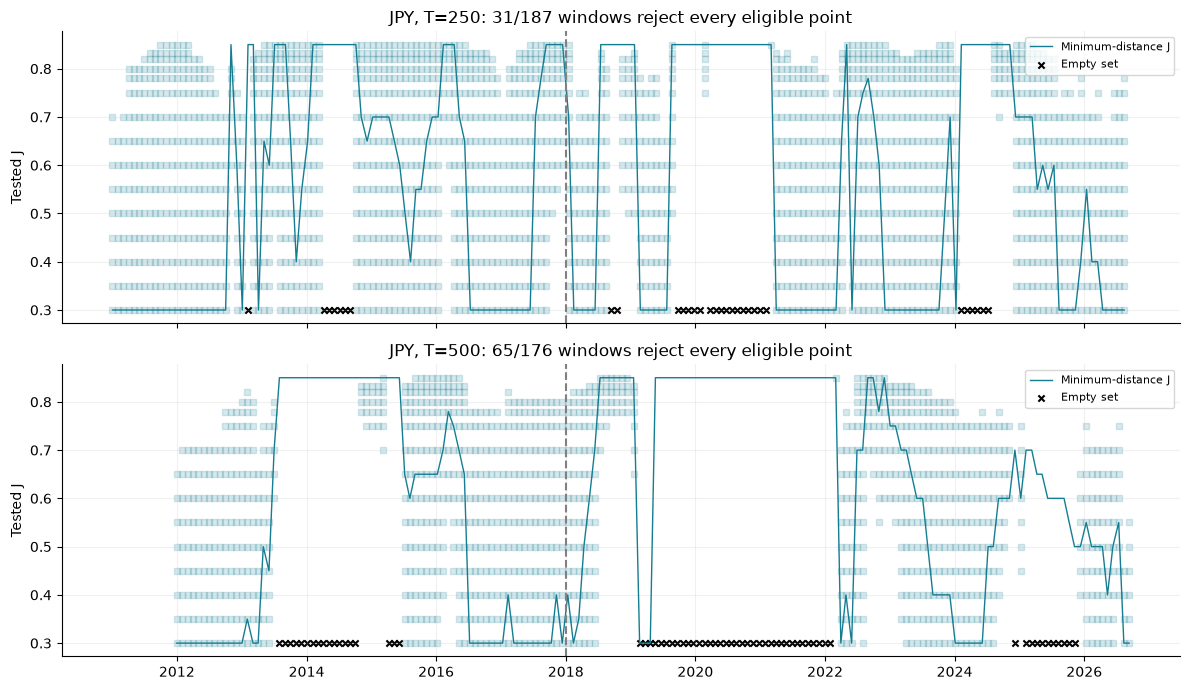

In [6]:
def draw_rolling(ax, pair, T):
    rows = result["pairs"][pair]["rolling"][str(T)]
    dates = pd.to_datetime([r["date"] for r in rows])
    for day, row in zip(dates, rows):
        ax.scatter([day]*len(row["confidence_set"]), row["confidence_set"], marker="s", s=13,
                   alpha=.17, color=colors[pair])
    ax.plot(dates, [r["J_hat"] for r in rows], color=colors[pair], lw=1, label="Minimum-distance J")
    empty = np.array([r["empty_set"] for r in rows])
    ax.scatter(dates[empty], [sim["eligible"][pair][0]]*empty.sum(), marker="x", color="black", s=20, label="Empty set")
    ax.axvline(pd.Timestamp(design["split"]), color="grey", ls="--")
    ax.set(ylabel="Tested J", title=f"{pair}, T={T}: {empty.sum()}/{len(rows)} windows reject every eligible point")
    ax.legend(fontsize=8)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, T in zip(axes, design["windows"]): draw_rolling(ax, "JPY", T)
plt.tight_layout(); plt.show()

### A non-rejection is not evidence of carry dynamics

The Gaussian negative control below is evaluated using the identical FX banks. Frequent
non-rejection of independent Gaussian returns would show that this statistic admits a
process with no carry channel. This limits the meaning of broad confidence sets and
belongs beside the rolling result, even if an event association is positive.

In [7]:
display(pd.DataFrame([{k:v for k,v in row.items() if k not in ("J", "per_J_non_rejection")}
                      for row in result["gaussian"]]))

,pair,window,n,any_non_rejection_rate
0,JPY,250,500,0.802
1,JPY,500,500,0.484
2,EUR,250,500,0.804
3,EUR,500,500,0.500


## Exhibit 6 - The predeclared carry-unwind proxy test

An episode needs prior net short exposure >=5% of OI, a weekly reduction >=5 percentage
points, and currency appreciation >=1.5 pre-interval SD times sqrt(sessions). SD uses the prior 250
observations. Events are separated by 42 sessions; report gaps above 10 calendar days
are excluded. This is a short-covering proxy, not direct identification of carry trades.

Scores use the last available monthly J_hat over 21 sessions **before the price/positioning
interval starts**. Match five non-episode dates in the same year with log-volatility
difference <=0.25. Dates within 42 sessions of an episode are excluded from controls.
Unmatched episodes are reported. Label permutations select pseudo-episode dates within
matched sets and recompute the contrast; 95% effect intervals bootstrap event-year clusters.

COT Tuesday observation labels are retrospective; publication is generally Friday and
holidays can delay it. This is historical association evaluation, not a real-time alert
backtest. The matched-label permutation assumes exchangeability, which overlapping
estimates and reused controls only approximate. Small numbers of years weaken the interval.

,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,mc_lo,mc_hi,status
0,JPY,500,validation,5,2,None,None,None,None,None,None,insufficient_events


**Primary JPY test is not estimable with the matched episodes available**

Descriptive mean of available matched differences: 0.071. No confidence interval or permutation p-value is reported with fewer than three matched episodes.

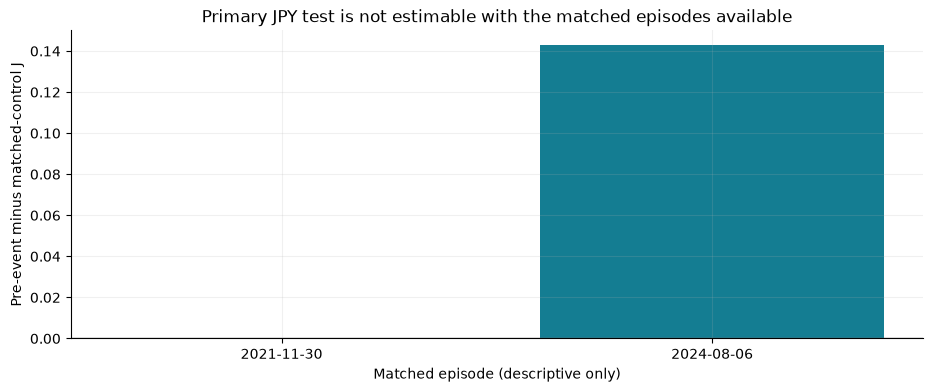

,start_position,end_position,date,interval_start,net_short_before,net_short_fall,appreciation,appreciation_z,year,score,difference,pre_event_empty_set_fraction
0,2975,2978,2021-11-30,2021-11-23,0.240424,0.060893,0.015425,2.359387,2021,0.850000,1.110223e-16,1.0
1,3645,3649,2024-08-06,2024-07-30,0.232006,0.151193,0.057641,4.530062,2024,0.461905,1.428571e-01,0.0


In [8]:
primary = next(row for row in result["specifications"] if row["primary"])
fields = ["pair", "window", "segment", "n_labelled", "n_matched", "effect", "lo", "hi", "p_value", "mc_lo", "mc_hi", "status"]
display(pd.DataFrame([{key: primary.get(key) for key in fields}]))
if primary["p_value"] is None:
    headline = "Primary JPY test is not estimable with the matched episodes available"
else:
    headline = f"Primary JPY result: {primary['status']}; effect={primary['effect']:.3f}, permutation p={primary['p_value']:.4f}"
display(Markdown("**" + headline + "**"))
fig, ax = plt.subplots()
ax.set(title=headline, xlabel="Event minus matched-control J", ylabel="Permutation draws")
if primary["permutation"]:
    ax.hist(primary["permutation"], bins=40, color="#8ba7b3")
    ax.axvline(primary["effect"], color=colors["JPY"], lw=2, label="Observed")
    ax.legend()
elif primary["matched"]:
    ax.bar([m["date"] for m in primary["matched"]], [m["difference"] for m in primary["matched"]], color=colors["JPY"])
    ax.axhline(0, color="grey", lw=1)
    ax.set(xlabel="Matched episode (descriptive only)", ylabel="Pre-event minus matched-control J")
    display(Markdown(f"Descriptive mean of available matched differences: "
                     f"{np.mean([m['difference'] for m in primary['matched']]):.3f}. "
                     "No confidence interval or permutation p-value is reported with fewer than three matched episodes."))
else:
    ax.text(.5, .5, "No matched episodes: no test", ha="center", transform=ax.transAxes)
plt.show()
display(pd.DataFrame(primary["matched"]).drop(columns=["control_positions", "control_scores"], errors="ignore"))

## Exhibit 7 - EUR falsification

EUR is a comparison market, not a proven carry-free negative control. The direct
falsification scores EUR on the same JPY episode dates; EUR's own short-covering labels
are also reported as secondary. Similar patterns would weaken carry specificity, but
would not by themselves prove the estimator is measuring noise. No EUR result can
replace an unfavourable primary JPY result.

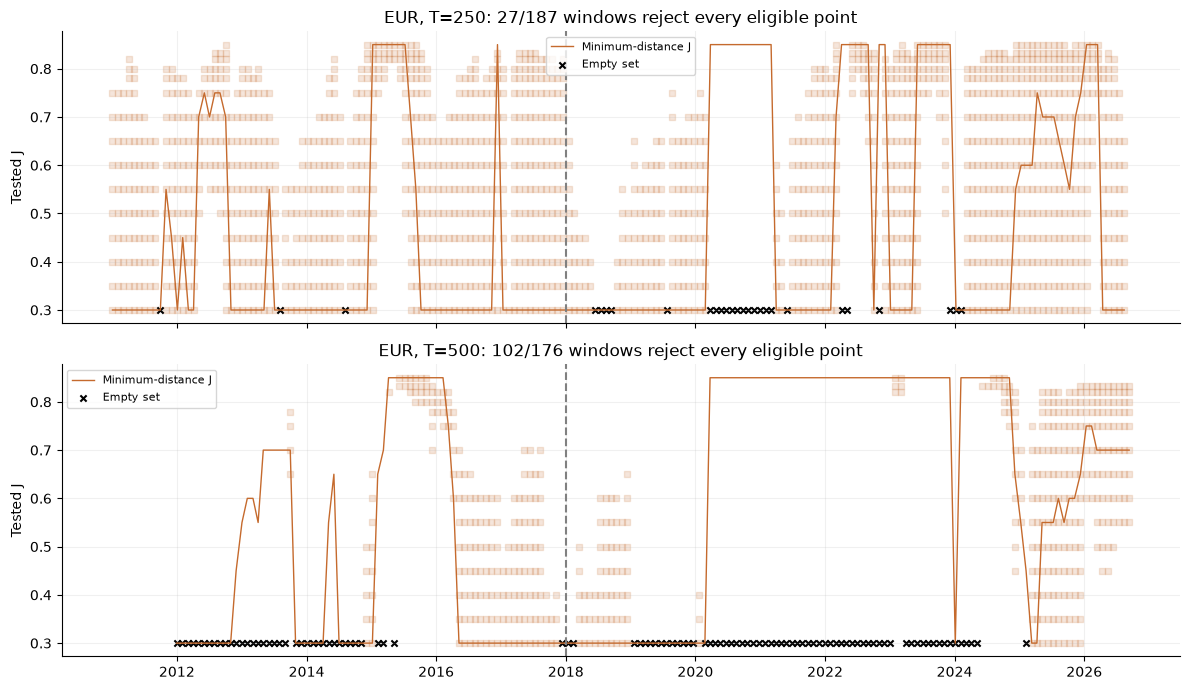

,label_pair,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,mc_lo,mc_hi,status
0,JPY,EUR,250,validation,5,2,None,None,None,None,None,None,insufficient_events
1,JPY,EUR,500,validation,5,2,None,None,None,None,None,None,insufficient_events
2,EUR,EUR,250,validation,1,0,None,None,None,None,None,None,insufficient_events
3,EUR,EUR,500,validation,1,0,None,None,None,None,None,None,insufficient_events


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, T in zip(axes, design["windows"]): draw_rolling(ax, "EUR", T)
plt.tight_layout(); plt.show()
control_specs = [r for r in result["specifications"] if r["pair"] == "EUR" and r["segment"] == "validation"]
display(pd.DataFrame([{k:r.get(k) for k in ["label_pair", *fields]} for r in control_specs]))

## Exhibit 8 - Fixed-split, sequential held-out evaluation

The split is 1 January 2018. Innovation scales, J banks, thresholds and window choices
were frozen using the earlier segment/design. Each later rolling estimate uses only
observations available by its endpoint. Annual summaries show subsequent performance.
This implements a fixed-split validation evaluated sequentially, **not** an expanding
nuisance-parameter refit. Data are the current historical vintage, not archived real-time
releases. Event/control matching remains retrospective and must not be sold as forecasting.

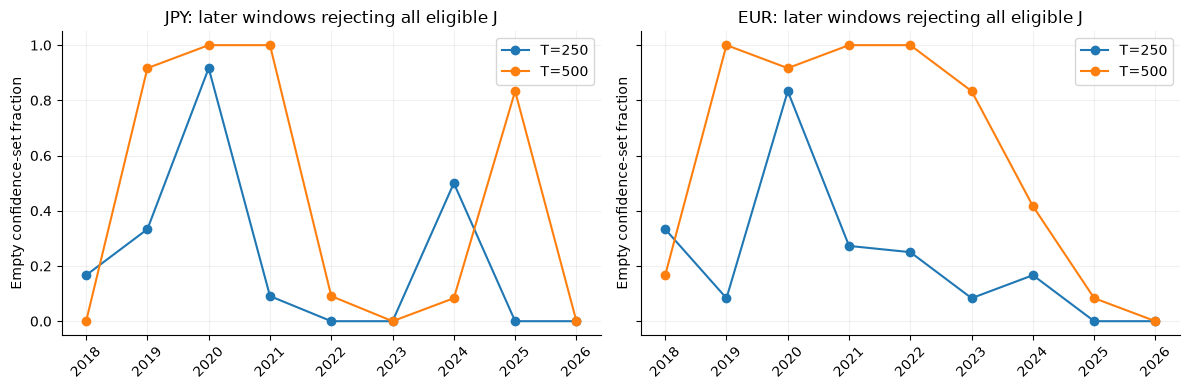

,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,mc_lo,mc_hi,status
0,JPY,500,training,2,2,None,None,None,None,None,None,insufficient_events
1,JPY,500,validation,5,2,None,None,None,None,None,None,insufficient_events


In [10]:
walk = pd.DataFrame(result["walk_forward"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pair in zip(axes, ("JPY", "EUR")):
    for T in design["windows"]:
        sub = walk[(walk.pair == pair) & (walk.window == T)]
        ax.plot(sub.year, sub.empty_set_fraction, "o-", label=f"T={T}")
    ax.tick_params(axis="x", rotation=45)
    ax.set(title=pair + ": later windows rejecting all eligible J", ylabel="Empty confidence-set fraction")
    ax.legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame([{k:r.get(k) for k in fields} for r in result["specifications"]
                      if r["pair"] == "JPY" and r["window"] == 500]))

## Exhibit 9 - FX-scale calibration and power

Positive controls use 500 independent true-model pseudo-samples at two eligible J values,
both window lengths and both solved scales. Wilson intervals are compared with nominal
10% size. Any failures remain in the table; the test's finite-sample calibration cannot
be assumed from the WTI work. Power contrasts J=0.40 with the declared eligible comparison.
Common seeds across J/pairs/horizons induce correlated Monte Carlo errors and cannot be
counted as independent replications. The 500 calibration/999 null paths are new FX runs.

,pair,window,J,n,rejections,rate,lo,hi,covers_nominal
0,JPY,250,0.40,500,40,0.080,0.059298,0.107106,True
1,JPY,250,0.78,500,48,0.096,0.073174,0.124987,True
2,JPY,500,0.40,500,54,0.108,0.083723,0.138255,True
3,JPY,500,0.78,500,45,0.090,0.067943,0.118309,True
4,EUR,250,0.40,500,39,0.078,0.057581,0.104854,True
5,EUR,250,0.78,500,52,0.104,0.080194,0.133844,True
6,EUR,500,0.40,500,53,0.106,0.081957,0.136051,True
7,EUR,500,0.78,500,48,0.096,0.073174,0.124987,True


JPY: first tested lower-bound crossing of 80% is bracketed by 500-1000 sessions.

EUR: first tested lower-bound crossing of 80% is bracketed by 500-1000 sessions.

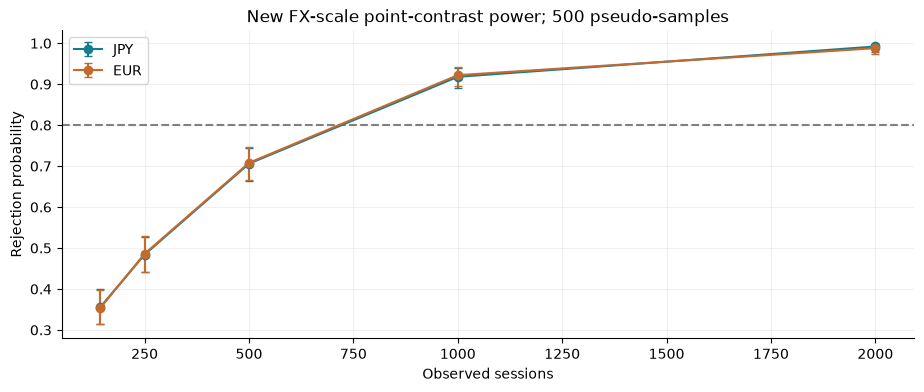

Controls whose 95% interval misses nominal size: **0/8**.

In [11]:
controls = pd.DataFrame(result["controls"])
display(controls)
power = pd.DataFrame(result["power"])
fig, ax = plt.subplots()
for pair in ("JPY", "EUR"):
    sub = power[power.pair == pair]
    ax.errorbar(sub["T"], sub.power,
                yerr=[sub.power-sub.lo, sub.hi-sub.power], fmt="o-", color=colors[pair], label=pair, capsize=3)
    crossing = sub.loc[sub.lo > .8, "T"]
    if len(crossing):
        first = int(crossing.iloc[0]); previous = max([t for t in design["power_lengths"] if t < first], default=0)
        display(Markdown(f"{pair}: first tested lower-bound crossing of 80% is bracketed by {previous}-{first} sessions."))
    else:
        display(Markdown(f"{pair}: no tested lower confidence bound exceeds 80% power."))
ax.axhline(.8, ls="--", color="grey")
ax.set(xlabel="Observed sessions", ylabel="Rejection probability", title="New FX-scale point-contrast power; 500 pseudo-samples")
ax.legend(); plt.show()
display(Markdown(f"Controls whose 95% interval misses nominal size: **{int((~controls.covers_nominal).sum())}/{len(controls)}**."))

## Exhibit 10 - What the simulated regime contrast means over 21 sessions

These are unconditional regime contrasts at the solved scales. Each path discards 500
burn-in returns, rebuilds prices from 1, and evaluates exactly 21 returns. Round trips
require recovery evidence and ending drawdown, not maximum drawdown alone. Recovery
refers to regaining the pre-trough peak after the maximum drawdown; unrecovered paths
are censored at 21. Recovery after >=5% drawdown can have very few qualifying paths at FX
scale; a zero denominator is undefined and displayed as missing.

,pair,J,horizon,n,mdd_mean,mdd_p95,terminal_mean,ending_drawdown_mean,qualifying_5pct,recovered_5pct,recovery_rate,recovery_lo,recovery_hi,median_recovery_sessions_if_observed
0,JPY,0.40,21,500,0.039674,0.086966,-0.006073,0.029237,148,2,0.013514,0.003714,0.047929,4.5
1,JPY,0.78,21,500,0.056322,0.137879,-0.021853,0.047413,234,5,0.021368,0.009161,0.049036,4.0
2,EUR,0.40,21,500,0.037724,0.081654,-0.005812,0.027801,129,2,0.015504,0.004262,0.054767,4.0
3,EUR,0.78,21,500,0.053628,0.130450,-0.020728,0.045143,230,5,0.021739,0.009321,0.049871,4.5


Recovery estimates have few observed recoveries; overlapping intervals do not establish a regime difference. Ending drawdowns and terminal returns describe persistence separately from maximum drawdown.

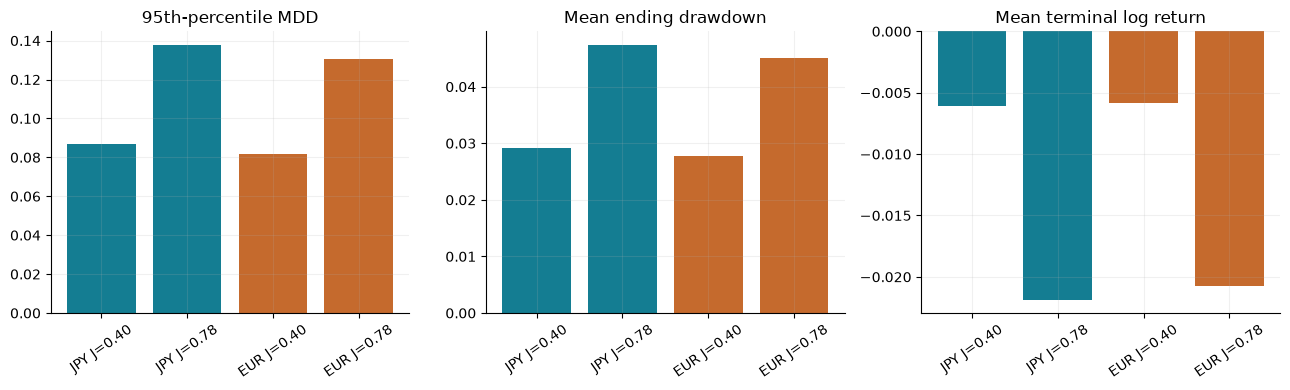

In [12]:
horizons = pd.DataFrame(result["horizons"])
display(horizons)
display(Markdown("Recovery estimates have few observed recoveries; overlapping intervals do not establish a regime difference. "
                 "Ending drawdowns and terminal returns describe persistence separately from maximum drawdown."))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = [f"{r['pair']} J={r['J']:.2f}" for r in result["horizons"]]
for ax, metric, title in zip(axes, ["mdd_p95", "ending_drawdown_mean", "terminal_mean"],
                              ["95th-percentile MDD", "Mean ending drawdown", "Mean terminal log return"]):
    ax.bar(labels, horizons[metric], color=[colors[r["pair"]] for r in result["horizons"]])
    ax.tick_params(axis="x", rotation=35)
    ax.set_title(title)
plt.tight_layout(); plt.show()

## Conclusion and limits

The primary result above controls the headline. Secondary specifications cannot rescue it.
An association would support further investigation of this statistic; it would not identify
the carry mechanism. A null leaves the hypothesis unsupported under this design.

- Gaussian innovations and the measured kurtosis gap limit tail realism. ACF adequacy
  deliberately excludes tail behaviour; passing it is not a distributional validation.
- Central-bank intervention, policy announcements and peg breaks are external mechanisms
  absent from PBMRS, analogous to the supply-shock limitation in the WTI work.
- One simulator step equals one observed trading session by assumption. Holidays leave
  varying calendar-time gaps. FX H.10 rates and COT observation times do not coincide exactly.
- Fixed sigma at a reference J and fixed other base.yaml parameters make J conditional, not a
  uniquely identified structural measure. Drifts, nuisance estimation uncertainty and
  nonstationarity are not included in the pointwise inversion sets.
- Carry labels use one futures category and thresholds chosen before results, but they
  remain imperfect proxies. Matched permutations require approximate exchangeability;
  overlapping windows and reused controls limit precision. Historical labels are not live signals.
- The finite grid bounds any conclusion. A final eligible point does not establish a
  continuous stable interval. J*beta=1 is only a theoretical agent-layer reference.

Next work: obtain the GMSG FX report, preregister a claim from it, test independent vintages
and markets, and revisit innovations or policy-jump mechanisms if the tail gap remains.

## Appendix A - Every specification, including nulls and exclusions

In [13]:
display(pd.DataFrame([{k:r.get(k) for k in ["primary", "label_pair", *fields]}
                      for r in result["specifications"]]))
excluded = [{"pair": r["pair"], "window": r["window"], "segment": r["segment"],
             "label_pair": r["label_pair"], **e} for r in result["specifications"] for e in r["excluded"]]
display(pd.DataFrame(excluded))

,primary,label_pair,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,mc_lo,mc_hi,status
0,False,JPY,JPY,250,training,2,2,None,None,None,None,None,None,insufficient_events
1,False,JPY,JPY,250,validation,5,2,None,None,None,None,None,None,insufficient_events
2,False,JPY,JPY,500,training,2,2,None,None,None,None,None,None,insufficient_events
3,True,JPY,JPY,500,validation,5,2,None,None,None,None,None,None,insufficient_events
4,False,JPY,EUR,250,training,2,1,None,None,None,None,None,None,insufficient_events
5,False,JPY,EUR,250,validation,5,2,None,None,None,None,None,None,insufficient_events
6,False,JPY,EUR,500,training,2,1,None,None,None,None,None,None,insufficient_events
7,False,JPY,EUR,500,validation,5,2,None,None,None,None,None,None,insufficient_events
8,False,EUR,EUR,250,training,2,1,None,None,None,None,None,None,insufficient_events
9,False,EUR,EUR,250,validation,1,0,None,None,None,None,None,None,insufficient_events


,pair,window,segment,label_pair,start_position,end_position,date,interval_start,net_short_before,net_short_fall,appreciation,appreciation_z,reason
0,JPY,250,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
1,JPY,250,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
2,JPY,250,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls
3,JPY,500,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
4,JPY,500,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
5,JPY,500,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls
6,EUR,250,training,JPY,1411,1415,2015-08-25,2015-08-18,0.423064,0.108933,0.036680,2.925031,insufficient prehistory or matched controls
7,EUR,250,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
8,EUR,250,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
9,EUR,250,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls


## Appendix B - Complete stability, numerical solve and Monte Carlo checks
Per-window rows, distances, p-values, Wilson bounds and borderline flags are retained in
`fx_cache/results.json`; no point is selected by p-value rank.

In [14]:
display(pd.concat([pd.DataFrame(sim["stability"][p]).assign(pair=p) for p in ("JPY", "EUR")], ignore_index=True))
display(pd.concat([pd.DataFrame(sim["scale"][p]["trace"]).assign(pair=p) for p in ("JPY", "EUR")], ignore_index=True))
display(pd.DataFrame(result["power"]))
display(pd.DataFrame(result["walk_forward"]))

,J,count,n,fraction,lo,hi,pair
0,0.300000,0,500,0.000,4.336809e-19,0.007624,JPY
1,0.350000,0,500,0.000,4.336809e-19,0.007624,JPY
2,0.400000,0,500,0.000,4.336809e-19,0.007624,JPY
3,0.450000,0,500,0.000,4.336809e-19,0.007624,JPY
4,0.500000,0,500,0.000,4.336809e-19,0.007624,JPY
5,0.550000,0,500,0.000,4.336809e-19,0.007624,JPY
6,0.600000,0,500,0.000,4.336809e-19,0.007624,JPY
7,0.650000,0,500,0.000,4.336809e-19,0.007624,JPY
8,0.700000,0,500,0.000,4.336809e-19,0.007624,JPY
9,0.750000,0,500,0.000,4.336809e-19,0.007624,JPY


,sigma_eps,total_sd,pair
0,0.000010,0.001420,JPY
1,0.015000,0.016965,JPY
2,0.007505,0.008439,JPY
3,0.003757,0.004381,JPY
4,0.005631,0.006385,JPY
5,0.004694,0.005374,JPY
6,0.005163,0.005878,JPY
7,0.005397,0.006131,JPY
8,0.005514,0.006258,JPY
9,0.005456,0.006195,JPY


,pair,T,null_J,truth_J,n,rejections,power,lo,hi
0,JPY,144,0.4,0.78,500,178,0.356,0.315275,0.398921
1,JPY,250,0.4,0.78,500,242,0.484,0.440485,0.527759
2,JPY,500,0.4,0.78,500,353,0.706,0.664617,0.744242
3,JPY,1000,0.4,0.78,500,459,0.918,0.890645,0.938981
4,JPY,2000,0.4,0.78,500,496,0.992,0.979613,0.996885
5,EUR,144,0.4,0.78,500,177,0.354,0.313342,0.396884
6,EUR,250,0.4,0.78,500,243,0.486,0.442465,0.529748
7,EUR,500,0.4,0.78,500,354,0.708,0.666681,0.746148
8,EUR,1000,0.4,0.78,500,461,0.922,0.895146,0.942419
9,EUR,2000,0.4,0.78,500,494,0.988,0.974070,0.994489


,pair,window,year,n_windows,mean_J,empty_set_fraction,training_cutoff,nuisance_policy
0,JPY,250,2018,12,0.608333,0.166667,2018-01-01,frozen initial training
1,JPY,250,2019,12,0.575000,0.333333,2018-01-01,frozen initial training
2,JPY,250,2020,12,0.850000,0.916667,2018-01-01,frozen initial training
3,JPY,250,2021,11,0.400000,0.090909,2018-01-01,frozen initial training
4,JPY,250,2022,12,0.544167,0.000000,2018-01-01,frozen initial training
5,JPY,250,2023,12,0.350000,0.000000,2018-01-01,frozen initial training
6,JPY,250,2024,12,0.791667,0.500000,2018-01-01,frozen initial training
7,JPY,250,2025,12,0.500000,0.000000,2018-01-01,frozen initial training
8,JPY,250,2026,8,0.356250,0.000000,2018-01-01,frozen initial training
9,JPY,500,2018,12,0.662500,0.000000,2018-01-01,frozen initial training


## Appendix C - Reproduction, hashes and provenance

Raw payloads are committed byte-for-byte with URL, UTC retrieval timestamp, byte count and
SHA-256. Git attributes prevent Windows newline conversion. Simulation blobs also carry
content hashes and input-dependent keys. Source fingerprints normalize source line endings
only; raw response hashes never do. No Yahoo dependency is used.

From the project environment, run `build_fx_data.py`, `build_fx_simulations.py`,
`build_fx_results.py`, then `build_fx_notebook.py` in this notebook directory. Only the
data builder needs a network on an uncached run. Existing verified caches support offline
execution; simulation generation is deliberately separate from presentation.

In [15]:
display(pd.DataFrame([{"file": name, **entry} for name, entry in
                     validate_raw_tree(CACHE / "raw").items()]))
display(pd.DataFrame([{"name": k, "value": v} for k,v in design["seeds"].items()]))
display(pd.DataFrame([{"package": k, "version": v} for k,v in manifest["versions"].items()]))
print("Git HEAD at computation:", manifest["git_head"])
print("Python:", manifest["python"])
print("Simulation input hash:", sim["root_key"])
print("Result payload SHA-256:", manifest["results_sha256"])
display(pd.DataFrame([{"path": k, "source_sha256": v} for k,v in manifest["sources"].items()]))
print("All raw, source and simulation manifests validated at notebook start.")

,file,byte_count,cache_file,request_parameters,retrieved_at_utc,sha256,source_name,url
0,EUR_099741/cftc_6dca-aqww_2010-01-01_2026-09-1...,141400,cftc_6dca-aqww_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Cnoncomm_...,2026-09-15T15:40:56.173892+00:00,cb321d6aefe6de43ba226ee375d3e474aa62bf1cfc362a...,cftc_6dca-aqww_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/6dca...
1,EUR_099741/cftc_gpe5-46if_2010-01-01_2026-09-1...,137142,cftc_gpe5-46if_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Clev_mone...,2026-09-15T15:40:58.608531+00:00,8b900601e19a8eeda707231c41c7a317a5b8945c31022a...,cftc_gpe5-46if_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/gpe5...
2,EUR_099741/cftc_jun7-fc8e_2010-01-01_2026-09-1...,141390,cftc_jun7-fc8e_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Cnoncomm_...,2026-09-15T15:40:57.422030+00:00,e839a9fe7855fb972530941c3f6fe93b5c009de4da1beb...,cftc_jun7-fc8e_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/jun7...
3,EUR_099741/cftc_yw9f-hn96_2010-01-01_2026-09-1...,137118,cftc_yw9f-hn96_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Clev_mone...,2026-09-15T15:40:59.478732+00:00,8360857344fc02836ea70b3fda5e79c246d15da3570b7d...,cftc_yw9f-hn96_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/yw9f...
4,JPY_097741/cftc_6dca-aqww_2010-01-01_2026-09-1...,140619,cftc_6dca-aqww_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Cnoncomm_...,2026-09-15T15:40:49.523152+00:00,b1a8134687a144f1988c0907f06f8ed25bab4cc678d1f6...,cftc_6dca-aqww_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/6dca...
5,JPY_097741/cftc_gpe5-46if_2010-01-01_2026-09-1...,136889,cftc_gpe5-46if_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Clev_mone...,2026-09-15T15:40:52.169192+00:00,e74ea7b330f7702484afce2032e72dddec71166ddc0bea...,cftc_gpe5-46if_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/gpe5...
6,JPY_097741/cftc_jun7-fc8e_2010-01-01_2026-09-1...,140624,cftc_jun7-fc8e_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Cnoncomm_...,2026-09-15T15:40:50.754114+00:00,2f7b9c831a0154292ffb5f358fca0235e78d8c91a558ff...,cftc_jun7-fc8e_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/jun7...
7,JPY_097741/cftc_yw9f-hn96_2010-01-01_2026-09-1...,136900,cftc_yw9f-hn96_2010-01-01_2026-09-15.json,%24select=report_date_as_yyyy_mm_dd%2Clev_mone...,2026-09-15T15:40:53.397457+00:00,474dc6d730bcff8bb2c54f8793fa6a33ed0b1cda3ac368...,cftc_yw9f-hn96_2010-01-01_2026-09-15.json,https://publicreporting.cftc.gov/resource/yw9f...
8,cftc_catalog.json,129,cftc_catalog.json,domains=publicreporting.cftc.gov&limit=100,2026-09-15T15:38:58.901022+00:00,d5184acae98546b25335c1fd6c5a2562a34aeba56a5238...,cftc_catalog.json,https://api.us.socrata.com/api/catalog/v1?doma...
9,cftc_contract_legacy_combined_EUR.json,109,cftc_contract_legacy_combined_EUR.json,%24select=distinct+market_and_exchange_names%2...,2026-09-15T15:40:56.788577+00:00,5b7a80f5392d5765225a2932bc36b29bf34f4a3c414532...,cftc_contract_legacy_combined_EUR.json,https://publicreporting.cftc.gov/resource/jun7...


,name,value
0,solver,"[700000, 700099]"
1,stability,"[710000, 710499]"
2,calibration,"[720000, 720499]"
3,null,"[720500, 721498]"
4,pseudo,"[730000, 730499]"
5,horizon,"[740000, 740499]"
6,bootstrap,750000
7,permutation,760000
8,gaussian,"[770000, 770499]"


,package,version
0,pbmrs,0.2.2
1,numpy,2.5.1
2,pandas,3.0.5
3,matplotlib,3.11.2
4,nbformat,5.11.1
5,nbclient,0.11.0


Git HEAD at computation: e2b61c85bb540dce5f06244a68d49d8eb684913c
Python: 3.14.4
Simulation input hash: a08a29d5868fcb8c92aa75081c248cb561c168eb89456b226ad3faa86fae0e17
Result payload SHA-256: 446f7376a7a7395c3770c468c10dd25164315814193d8ae21bd9a6647744dc2d


,path,source_sha256
0,configs/base.yaml,7891412cb1e8d337d374b4ff78dd0436d7ab4df951001f...
1,configs/fx_study.json,d5bd9607cbae2c0f1bfa7b027c9d0efb8d6fcb900db8be...
2,notebooks/build_fx_data.py,36e1d5bb672b217bb86a1869d885f965535c644d5d8737...
3,notebooks/build_fx_notebook.py,bdc42a6df35413165caf4253f9d68ca1255613401531cc...
4,notebooks/build_fx_results.py,1fa1abc2453c40c949dabeb6a85d74f977a7b05633d17b...
5,notebooks/build_fx_simulations.py,1209a4719c143300934e0a308a9735065423ddc21ecf9f...
6,src/pbmrs_core/__init__.py,fc0a69311b748886a7ec42bfa129def3bbd56281cfefe4...
7,src/pbmrs_core/__main__.py,02af12b58da551df39bcf6388042b691f435b919bbbbad...
8,src/pbmrs_core/_init_.py,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...
9,src/pbmrs_core/agents.py,7e9129c409af44877ae5cfc960e676de6d64695b2d0ca9...


All raw, source and simulation manifests validated at notebook start.
